# 1. make classification data and get it ready



In [2]:
import sklearn
from sklearn.datasets import make_circles

# make 1000 samples
n_samples =1000

# create circles
x,y= make_circles(n_samples,noise = 0.03, random_state=42)

In [3]:
len(x),len(y)

(1000, 1000)

In [4]:
print(f"frst 5 samples of X:\n {x[:5]}")
print(f"frst 5 samples of Y:\n {y[:5]}")


frst 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
frst 5 samples of Y:
 [1 1 1 1 0]


In [5]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [6]:
x[:10]

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       [-0.39373073,  0.69288277],
       [ 0.44220765, -0.89672343],
       [-0.47964637,  0.67643477],
       [-0.01364836,  0.80334872],
       [ 0.77151327,  0.14775959],
       [-0.16932234, -0.79345575],
       [-0.1214858 ,  1.02150905]])

In [7]:
import pandas as pd
import numpy as np

circles=pd.DataFrame({"X1":x[:,0],
                      "X2":x[:,1],
                      "label":y})

circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


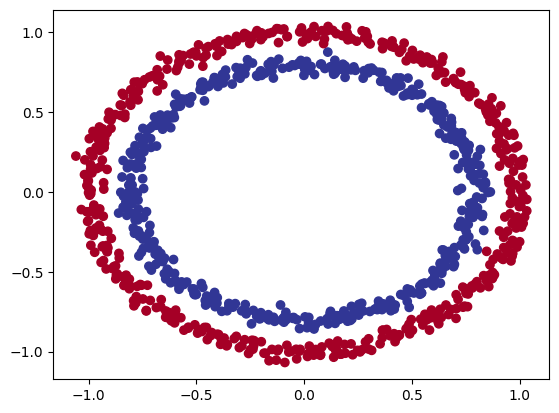

In [8]:
# visualize
import matplotlib.pyplot as plt

plt.scatter(x=x[:,0],y=x[:,1],c=y,cmap=plt.cm.RdYlBu)

Note: a toy dataset for practice like a number randome number is a blue circle or the red cirle

# check input and output shapes



In [9]:
x.shape,y.shape

((1000, 2), (1000,))

In [10]:
# view first example of features and labels

x_sample = x[0]
y_sample=y[0]

x_sample,y_sample

(array([0.75424625, 0.23148074]), np.int64(1))

In [11]:
type(x),x.dtype

(numpy.ndarray, dtype('float64'))

## 1.2 Turn data into tensors

In [12]:
# turn data into tensors

import torch

x=torch.from_numpy(x).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [13]:
x[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [14]:
# split data into training and testing sets

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
len(x_train),len(x_test)

(800, 200)

## building a model

In [16]:
import torch
from torch import nn

device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [17]:
x_train,x_train.shape

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         ...,
         [ 0.0157, -1.0300],
         [ 1.0110,  0.1680],
         [ 0.5578, -0.5709]]),
 torch.Size([800, 2]))

# constructing a model

In [18]:
# 1. construct a model

class CircleModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1=nn.Linear(in_features=2,out_features=5)
    self.layer_2=nn.Linear(in_features=5,out_features=1)



  # define a forward() methd that outlines the forward pass
  def forward(self,x):
    return self.layer_2(self.layer_1(x))

  # 4. instantiate an instance of our model class and send it to the target device
model_0=CircleModel()
model_0




CircleModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [19]:
model_0.layer_1

Linear(in_features=2, out_features=5, bias=True)

In [20]:
model_0.layer_1.weight

Parameter containing:
tensor([[ 0.6446,  0.6175],
        [ 0.3386, -0.2163],
        [-0.4982,  0.3911],
        [ 0.4618,  0.3246],
        [ 0.4590,  0.1363]], requires_grad=True)

In [21]:
model_0.layer_1.bias

Parameter containing:
tensor([ 0.6861, -0.6829,  0.5528, -0.0048,  0.1518], requires_grad=True)

## to change the model parameters to the device than do:

next(model_0.parameters()).device

# replicate the model with the sequential to look into it

1. model_0=nn.Sequential(
2.    nn.Linear(in_features=2,out_features=5),
3.    nn.Linear(in_features=5,out_features=1)
4. )
5. model_0

In [22]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.6446,  0.6175],
                      [ 0.3386, -0.2163],
                      [-0.4982,  0.3911],
                      [ 0.4618,  0.3246],
                      [ 0.4590,  0.1363]])),
             ('layer_1.bias',
              tensor([ 0.6861, -0.6829,  0.5528, -0.0048,  0.1518])),
             ('layer_2.weight',
              tensor([[-0.1663,  0.3976, -0.2174, -0.2739,  0.2116]])),
             ('layer_2.bias', tensor([-0.0967]))])

In [23]:
# make prediction
with torch.inference_mode():
  untrained_pred=model_0(x_test)
  print(f"length of prediction {len(untrained_pred)}, shape: {untrained_pred.shape}")

  print(f"length of test samples: {len(x_test)}, shape: {x_test.shape}")

  print(f"\n first 10 predictions:\n{untrained_pred[:10]}")

  print(f"\n first 10 labels:\n{y_test[:10]}")

length of prediction 200, shape: torch.Size([200, 1])
length of test samples: 200, shape: torch.Size([200, 2])

 first 10 predictions:
tensor([[-0.8367],
        [-0.8878],
        [-0.5387],
        [-0.9218],
        [-0.2780],
        [-0.3112],
        [-0.6615],
        [-0.5258],
        [-0.5501],
        [-0.8883]])

 first 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### Loss

Note: Binary Cross Entropy measures how far predicted probabilities are from the true labels.

**Logit:**

        the raw output of the neural network before applying sigmoid

Example neural network output:

          output = 2.3
          output = -1.5
          output = 0.8

They can be:

          (-∞ , +∞)

Logit → Probability:

      Logit	   Sigmoid Output
      -3	      0.047
      0	          0.5
      2	          0.88
      5	          0.99


**logit → sigmoid → probability**

In [24]:
# setup loss function and an optiizer

# loss_fn=nn.BCELoss() # BCELoss = requires input to have gone through the sigmoid activation function prior to input to BCELsoss

loss_fn=nn.BCEWithLogitsLoss()  # built in sigmoid activation function



# setup optimizer

optimizer=torch.optim.SGD(params=model_0.parameters(), lr=0.1)

model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.6446,  0.6175],
                      [ 0.3386, -0.2163],
                      [-0.4982,  0.3911],
                      [ 0.4618,  0.3246],
                      [ 0.4590,  0.1363]])),
             ('layer_1.bias',
              tensor([ 0.6861, -0.6829,  0.5528, -0.0048,  0.1518])),
             ('layer_2.weight',
              tensor([[-0.1663,  0.3976, -0.2174, -0.2739,  0.2116]])),
             ('layer_2.bias', tensor([-0.0967]))])

In [25]:
# claculate accuracy

def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100

  return acc






convert logits into ptrediction probabilities by passing them to some king of activation function and than convert model prediction probabilities to prediction labels by either rounding them or taking argmax

In [26]:
### view the first 5 output of the farword pass on the tst data
with torch. inference_mode():
  y_logits=model_0(x_test)[:5]

y_logits




tensor([[-0.8367],
        [-0.8878],
        [-0.5387],
        [-0.9218],
        [-0.2780]])

In [27]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [28]:
# use the sigmoid

y_pred_probs=torch.sigmoid(y_logits)

y_pred_probs

tensor([[0.3022],
        [0.2916],
        [0.3685],
        [0.2846],
        [0.4310]])

In [29]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]])

In [30]:
# find predicted labels

y_preds=torch.round(y_pred_probs)


# in full

# logit -> pred prob -> pred labels
y_pred_labels=torch.round(torch.sigmoid(model_0(x_test))[:5])


# check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))
# get rid of extra dimention

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.])

# teaining

steps

1. forward pass
2. calculate the loss
3. optimizer zero grad
4. loss backword (Backpropagation)
5. optimizer step(gradient decent)


Going from raw logits -> prediction probabilities -> prediction labels

our model outputs are going to be raw **logits**

In [31]:
model_0

CircleModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [32]:
# loss_fn=nn.BCELoss()
# loss_fn

In [33]:
torch.manual_seed(42)
# torch.cuda.manual_seed(42) # fro cuda...

# training

epochs=1000

for epoch in range(epochs):

  # setup training
  model_0.train()

  # forward pass
  y_logits=model_0(x_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits)) # turn logits into pred prob and pred prob into pred labels

  # # calculate BCELoss
  # loss=loss_fn(torch.sigmoid(y_logits), # nn.BCELoss this expect predictions probabilities as input
  #              y_train)


  # claculate loss/accuracy
  loss=loss_fn(y_logits,y_train) # nn.BCEWithLogitsLoss expects raw logits as input

  acc=accuracy_fn(y_true=y_train,y_pred=y_pred)


  # optimizer with zzero grade
  optimizer.zero_grad()

  # loss backword (backpropagation)
  loss.backward()

  # optimizer steps(optimize the parameter)
  optimizer.step()

  # testing

  model_0.eval()

  with torch.inference_mode():
    # forwad pass
    test_logits=model_0(x_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    # calculate the loss and accuracy

    test_loss=loss_fn(test_logits,y_test)
    test_acc= accuracy_fn(y_test,test_pred)

  # print whats  happening

  print(f"Epohs: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test_Loss: {test_loss:.5f} | Test_Accuracy: {test_acc:.2f}% ")



Epohs: 0 | Loss: 0.73972 | Accuracy: 50.00% | Test_Loss: 0.73009 | Test_Accuracy: 50.00% 
Epohs: 1 | Loss: 0.73422 | Accuracy: 50.00% | Test_Loss: 0.72529 | Test_Accuracy: 50.00% 
Epohs: 2 | Loss: 0.72940 | Accuracy: 50.00% | Test_Loss: 0.72112 | Test_Accuracy: 50.00% 
Epohs: 3 | Loss: 0.72519 | Accuracy: 50.00% | Test_Loss: 0.71748 | Test_Accuracy: 50.00% 
Epohs: 4 | Loss: 0.72150 | Accuracy: 50.00% | Test_Loss: 0.71430 | Test_Accuracy: 50.00% 
Epohs: 5 | Loss: 0.71826 | Accuracy: 50.00% | Test_Loss: 0.71153 | Test_Accuracy: 50.00% 
Epohs: 6 | Loss: 0.71543 | Accuracy: 50.00% | Test_Loss: 0.70912 | Test_Accuracy: 50.00% 
Epohs: 7 | Loss: 0.71294 | Accuracy: 50.00% | Test_Loss: 0.70701 | Test_Accuracy: 50.00% 
Epohs: 8 | Loss: 0.71076 | Accuracy: 50.00% | Test_Loss: 0.70517 | Test_Accuracy: 50.00% 
Epohs: 9 | Loss: 0.70884 | Accuracy: 50.00% | Test_Loss: 0.70357 | Test_Accuracy: 50.00% 
Epohs: 10 | Loss: 0.70716 | Accuracy: 50.00% | Test_Loss: 0.70216 | Test_Accuracy: 50.00% 
Epohs: 11

## make predictions ad evaluate the model

In [34]:
# visulize


import requests

from pathlib import Path

# Download helper functions for learn pytorch repo

if Path ("helper_functions.py").is_file():
  print("helper_functions.py already exisits")

else:
  print("download helper_functions.py")
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)


from helper_functions import plot_predictions, plot_decision_boundary





download helper_functions.py


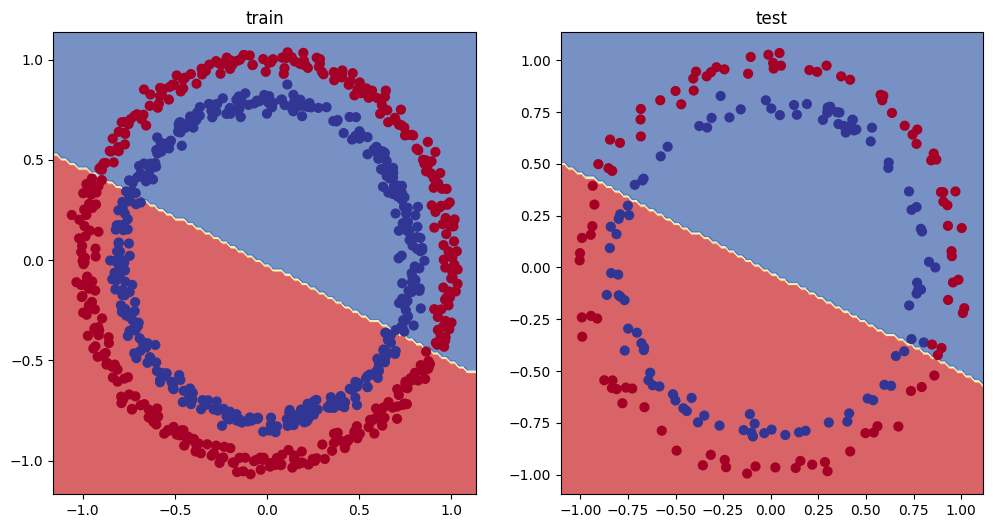

In [35]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_0,x_train,y_train)

plt.subplot(1,2,2)

plt.title("test")

plot_decision_boundary(model_0,x_test,y_test)


### improve a model (from a model perspective)

*  Add more layers - given the model more chances to learn about the pattern in the data

* Add more hidden unites  - we can go rom 5 hitden unites to 10 hidden unites


* fit for longer - give the model ore chances to learn (increase the epochs)

* changing the activation function also can add activation function with in the model

* change the learning rate

* change the loss function



In [36]:
# lets start

class CircleModelV4(nn.Module):
  def __init__(self):
    super().__init__()
    # nn.Sigmoid
    self.layer_1=nn.Linear(in_features=2,out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)
    self.relu=nn.ReLU()

  def forward(self,x):
    # return self.layer_3(self.layer_2(self.layer_1(x)))
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))




In [37]:
model_5=CircleModelV4()


In [38]:
model_5

CircleModelV4(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [39]:
# loss
loss_fn = nn.BCEWithLogitsLoss()

# optimizer
optimizer=torch.optim.SGD(params=model_5.parameters(),lr=0.1)

# acc


In [40]:
torch.manual_seed(42)

epochs=1000

for epoch in range(epochs):
  # setup train
  model_5.train()

  # forward pass
  y_logits=model_5(x_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  #calculate loss
  loss1=loss_fn(y_logits,y_train)

  # calculate accuracy
  acc1=accuracy_fn(y_train,y_pred)

  # grade zero
  optimizer.zero_grad()

  #bakpropagation
  loss1.backward()

  #optimize
  optimizer.step()

  # test
  model_5.eval()

  with torch.inference_mode():
    # farward
    test_logits=model_5(x_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    # calculate loss and accuracy
    test_loss1=loss_fn(test_logits,y_test)

    test_acc1=accuracy_fn(y_test,test_pred)
  # print whats  happening
  if epoch %100==0:
    print(f"Epohs: {epoch} | Loss: {loss1:.5f} | Accuracy: {acc1:.2f}% | Test_Loss: {test_loss1:.5f} | Test_Accuracy: {test_acc1:.2f}% ")




Epohs: 0 | Loss: 0.69295 | Accuracy: 50.00% | Test_Loss: 0.69319 | Test_Accuracy: 50.00% 
Epohs: 100 | Loss: 0.69115 | Accuracy: 52.88% | Test_Loss: 0.69102 | Test_Accuracy: 52.50% 
Epohs: 200 | Loss: 0.68977 | Accuracy: 53.37% | Test_Loss: 0.68940 | Test_Accuracy: 55.00% 
Epohs: 300 | Loss: 0.68795 | Accuracy: 53.00% | Test_Loss: 0.68723 | Test_Accuracy: 56.00% 
Epohs: 400 | Loss: 0.68517 | Accuracy: 52.75% | Test_Loss: 0.68411 | Test_Accuracy: 56.50% 
Epohs: 500 | Loss: 0.68102 | Accuracy: 52.75% | Test_Loss: 0.67941 | Test_Accuracy: 56.50% 
Epohs: 600 | Loss: 0.67515 | Accuracy: 54.50% | Test_Loss: 0.67285 | Test_Accuracy: 56.00% 
Epohs: 700 | Loss: 0.66659 | Accuracy: 58.38% | Test_Loss: 0.66322 | Test_Accuracy: 59.00% 
Epohs: 800 | Loss: 0.65160 | Accuracy: 64.00% | Test_Loss: 0.64757 | Test_Accuracy: 67.50% 
Epohs: 900 | Loss: 0.62362 | Accuracy: 74.00% | Test_Loss: 0.62145 | Test_Accuracy: 79.00% 


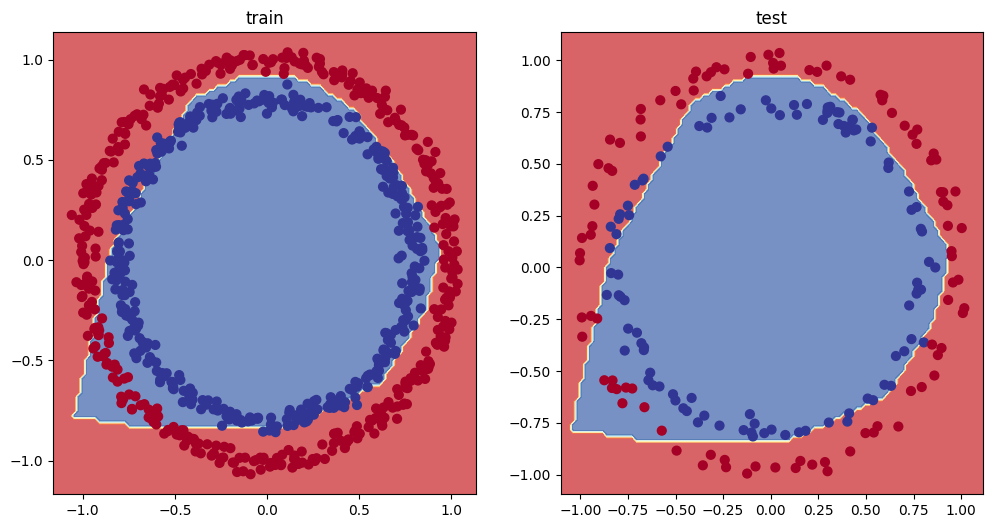

In [41]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_5,x_train,y_train)

plt.subplot(1,2,2)

plt.title("test")

plot_decision_boundary(model_5,x_test,y_test)


## Replicate None-linear functions

In [42]:
## create tensors
import torch
A= torch.arange(-10,10,1, dtype=torch.float32)
A.dtype

torch.float32

In [43]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

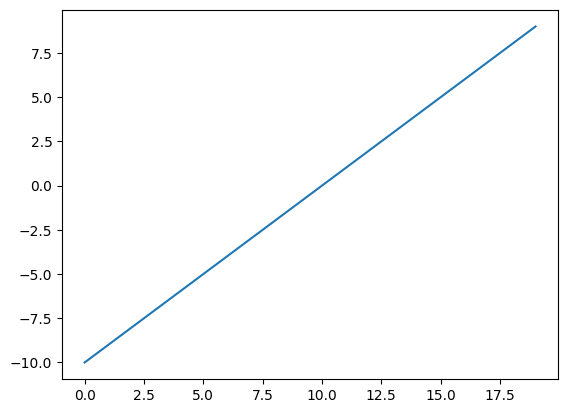

In [44]:
plt.plot(A)

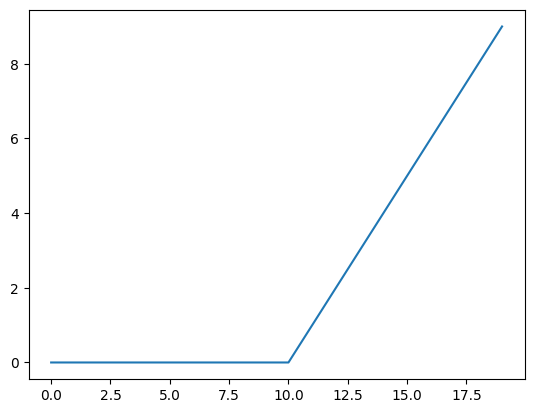

In [45]:
plt.plot(torch.relu(A))

In [46]:
torch.relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

In [47]:
def relu(x: torch.tensor)->torch.tensor:
  return torch.max(torch.tensor(0),x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

In [48]:
# lests replicate sigmoid function


B=torch.arange(-7,7,1,dtype=torch.float32)
B.dtype

torch.float32

In [49]:
B

tensor([-7., -6., -5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.])

In [50]:
torch.sigmoid(B)

tensor([9.1105e-04, 2.4726e-03, 6.6929e-03, 1.7986e-02, 4.7426e-02, 1.1920e-01,
        2.6894e-01, 5.0000e-01, 7.3106e-01, 8.8080e-01, 9.5257e-01, 9.8201e-01,
        9.9331e-01, 9.9753e-01])

In [51]:
def sigmoid(x:torch.tensor)->torch.tensor:
  s=1/(1+torch.exp(-x))
  return s
sigmoid(B)

tensor([9.1105e-04, 2.4726e-03, 6.6929e-03, 1.7986e-02, 4.7426e-02, 1.1920e-01,
        2.6894e-01, 5.0000e-01, 7.3106e-01, 8.8080e-01, 9.5257e-01, 9.8201e-01,
        9.9331e-01, 9.9753e-01])

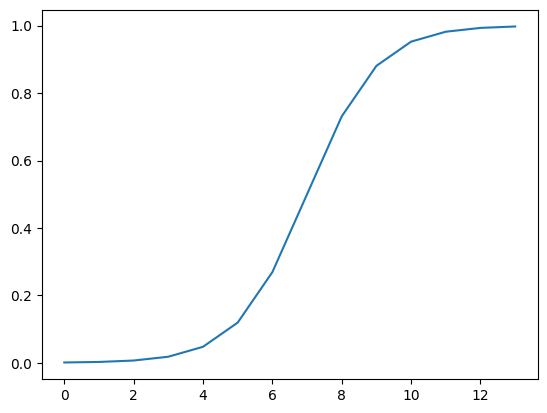

In [52]:
plt.plot(sigmoid(B))

## putting it all together in multiclass classification

* multiclass - more than one thing or another

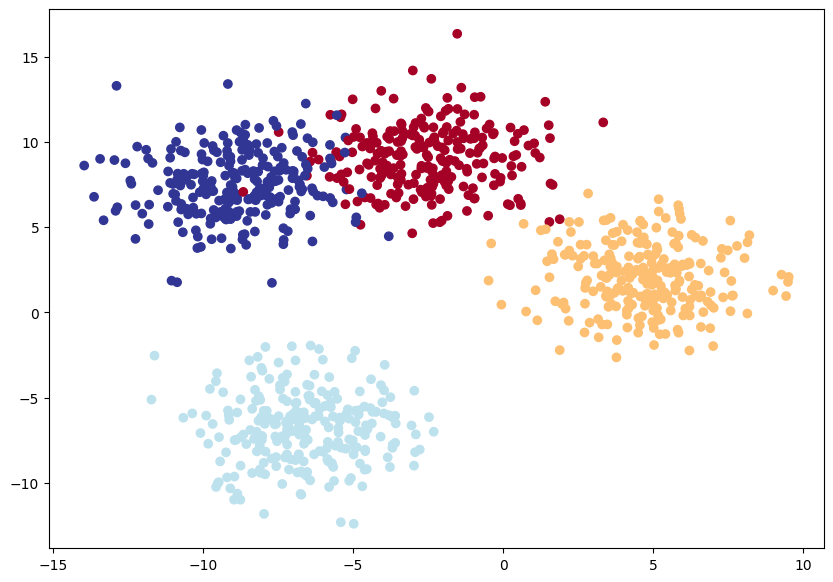

In [53]:
# create multiclass dataset

import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# set hyper parameters

NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=42


# create multiclass data

x_blob,y_blob=make_blobs(n_samples=1000,
                         n_features=NUM_FEATURES,
                         centers=NUM_CLASSES,
                         cluster_std=1.9,
                         random_state=RANDOM_SEED)



# turn data into tensors

x_blob=torch.from_numpy(x_blob).type(torch.float)
# y_blob=torch.from_numpy(y_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.long)



# 3 TRAIN_TEST_SPLIT
x_blob_train,x_blob_test,y_blob_train,y_blob_test=train_test_split(x_blob,y_blob,test_size=0.2,random_state=42)


# plot_vizualize the data
plt.figure(figsize=(10,7))

plt.scatter(x_blob[:,0],x_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)

In [54]:
x_blob[:5]

tensor([[-8.3001,  6.8316],
        [-5.4696, -6.3115],
        [-5.8188, -6.7357],
        [ 3.7671,  0.3585],
        [ 4.1467, -0.8828]])

In [55]:
y_blob[:5]

tensor([3, 2, 2, 1, 1])

In [56]:
# Building a multiclass model
from torch import nn
class MultiClassModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=5)
    self.layer_2=nn.Linear(in_features=5,out_features=5)
    self.layer_3=nn.Linear(in_features=5,out_features=1)
    self.tanh=torch.tanh(x)

    def forword(x):
      return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))


model_0=MultiClassModel()


In [57]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]])),
             ('layer_1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410])),
             ('layer_2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140],
                      [-0.2060, -0.0524, -0.1816,  0.2967, -0.3530],
                      [-0.2062, -0.1263, -0.2689,  0.0422, -0.4417],
                      [ 0.4039, -0.3799,  0.3453,  0.0744, -0.1452],
                      [ 0.2764,  0.0697,  0.3613,  0.0489, -0.1410]])),
             ('layer_2.bias',
              tensor([ 0.1202, -0.1213,  0.1882,  0.3993,  0.2585])),
             ('layer_3.weight',
              tensor([[-0.1955,  0.2582,  0.0800,  0.2271, -0.2726]])),
             ('layer_3.bias', tensor([-0.4427]))])

In [58]:
# loss and accuracy and optimizer
from sklearn.metrics import accuracy_score
loss_fn=nn.CrossEntropyLoss()


optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)


# accuracy=accuracy_score(y_true,y_pred)

In [59]:
class BlobModel(nn.Module):
  def __init__(self,input_features,output_features,hidden_units=8):
    super().__init__()

    self.linear_layer_stack=nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )


  def forward(self,x):
      return self.linear_layer_stack(x)

# create an instance
model_7=BlobModel(2,4)

In [60]:
x_blob_train.shape,y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [61]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

In [62]:
model_7.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[-0.2732, -0.5424],
                      [ 0.5802,  0.2037],
                      [ 0.2929,  0.2236],
                      [-0.0123,  0.5534],
                      [-0.5024,  0.0445],
                      [-0.4826,  0.2180],
                      [-0.2435,  0.2167],
                      [-0.1473,  0.5865]])),
             ('linear_layer_stack.0.bias',
              tensor([-0.4191, -0.4217, -0.4217,  0.6360,  0.2356,  0.6804, -0.5836, -0.7014])),
             ('linear_layer_stack.2.weight',
              tensor([[-0.2766, -0.2378,  0.1432,  0.1266,  0.2938, -0.1826, -0.2410,  0.1876],
                      [-0.1429,  0.2146, -0.0839,  0.2022, -0.2747, -0.1784,  0.1078,  0.0747],
                      [-0.0901,  0.2107,  0.2403, -0.2564, -0.1888,  0.3237, -0.1193, -0.1253],
                      [-0.3421, -0.2025,  0.0883, -0.0467, -0.2566,  0.0083, -0.2415, -0.3000],
                      [-0.1947, -0.3094, -0.225

In [63]:
model_7

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [64]:
# create loss functions

loss_fn=nn.CrossEntropyLoss()

# create optimizer

optimizer=torch.optim.SGD(params=model_7.parameters(),lr=0.1)



In [65]:
# building prediction probabilities for a multiclass pytorch model
with torch.inference_mode():
  y_pred=model_7(x_blob_test)
y_pred[:10]

tensor([[ 0.1972,  0.3204,  0.3514,  0.3563],
        [-0.4475, -0.1139, -0.2245,  0.1604],
        [-0.3328,  0.0821,  0.1826,  0.0641],
        [-0.1147,  0.2101,  0.2831,  0.1978],
        [ 0.2773,  0.2265,  0.0559,  0.4506],
        [-0.4532, -0.1379, -0.3443,  0.1929],
        [-0.2034,  0.1004,  0.1107,  0.1741],
        [-0.1392, -0.0050, -0.1874,  0.2997],
        [-0.3328,  0.0821,  0.1826,  0.0641],
        [ 0.0238,  0.1046, -0.1303,  0.3638]])

In [66]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

## getting prediction probabilities for a multiclass pytorch model

so inorder to evaluate and train and test out model, we need to convert our model's output(logits) to prediction probabilities and than to prediction labels

In [67]:
# conver out model logit outputs to prediction probabilitites

y_pred_probs=torch.softmax(y_pred,dim=1)
y_pred[:10],y_pred_probs[:10]

(tensor([[ 0.1972,  0.3204,  0.3514,  0.3563],
         [-0.4475, -0.1139, -0.2245,  0.1604],
         [-0.3328,  0.0821,  0.1826,  0.0641],
         [-0.1147,  0.2101,  0.2831,  0.1978],
         [ 0.2773,  0.2265,  0.0559,  0.4506],
         [-0.4532, -0.1379, -0.3443,  0.1929],
         [-0.2034,  0.1004,  0.1107,  0.1741],
         [-0.1392, -0.0050, -0.1874,  0.2997],
         [-0.3328,  0.0821,  0.1826,  0.0641],
         [ 0.0238,  0.1046, -0.1303,  0.3638]]),
 tensor([[0.2237, 0.2530, 0.2610, 0.2623],
         [0.1824, 0.2546, 0.2280, 0.3350],
         [0.1762, 0.2668, 0.2950, 0.2620],
         [0.1909, 0.2641, 0.2841, 0.2609],
         [0.2537, 0.2412, 0.2033, 0.3017],
         [0.1854, 0.2541, 0.2067, 0.3538],
         [0.1929, 0.2614, 0.2642, 0.2814],
         [0.2152, 0.2461, 0.2050, 0.3337],
         [0.1762, 0.2668, 0.2950, 0.2620],
         [0.2301, 0.2494, 0.1972, 0.3232]]))

In [68]:
torch.sum(y_pred_probs[0])

tensor(1.)

In [69]:
torch.max(y_pred_probs[0])

tensor(0.2623)

In [70]:
torch.argmax(y_pred_probs[0])

tensor(3)

In [71]:
torch.argmax(y_pred_probs[1])

tensor(3)

In [72]:
# convert prediction probabilities to prediction labels
y_pred_labels=torch.argmax(y_pred_probs,dim=1)

In [73]:
y_pred_labels[:10]

tensor([3, 3, 2, 2, 3, 3, 3, 3, 2, 3])

In [74]:
len(y_blob_train)

800

In [75]:
# create a trainig and testing loop for our multiclass model


torch.manual_seed(42)

epochs=200

for epoch in range(epochs):
  # training

  model_7.train()

  # forward pass

  y_logits=model_7(x_blob_train)
  # y_pred=torch.argmax(y_logits,dim=1)
  y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)

  #calculate loss

  loss = loss_fn(y_logits,y_blob_train)

  # calculate accuracy
  acc = accuracy_fn(y_blob_train,y_pred)

  #zero grad

  optimizer.zero_grad()

  #backpropagation

  loss.backward()

  #optimizer step

  optimizer.step()


  # testing

  model_7.eval()

  with torch.inference_mode():
    # forward pass

    test_logits=model_7(x_blob_test)
    # test_pred=torch.argmax(test_logits,dim=1)
    test_pred=torch.softmax(test_logits,dim=1).argmax(dim=1)

    # calculate loss
    test_loss=loss_fn(test_logits,y_blob_test)

    # calculate accuracy
    test_acc = accuracy_fn(y_blob_test,test_pred)


  # print
  if epoch%10==0:
    print(f"Epochs: {epoch}, | Training_Accuracy: {acc:.2f}%, | Train_loss: {loss:.4f} | Test_Accuraccy: {test_acc:.2f}% | test_loss: {test_loss:.4f}")



Epochs: 0, | Training_Accuracy: 54.75%, | Train_loss: 1.2901 | Test_Accuraccy: 77.00% | test_loss: 1.1458
Epochs: 10, | Training_Accuracy: 91.38%, | Train_loss: 0.7557 | Test_Accuraccy: 93.50% | test_loss: 0.7145
Epochs: 20, | Training_Accuracy: 95.38%, | Train_loss: 0.4868 | Test_Accuraccy: 97.00% | test_loss: 0.4793
Epochs: 30, | Training_Accuracy: 95.75%, | Train_loss: 0.3828 | Test_Accuraccy: 96.00% | test_loss: 0.3816
Epochs: 40, | Training_Accuracy: 96.00%, | Train_loss: 0.3281 | Test_Accuraccy: 96.00% | test_loss: 0.3268
Epochs: 50, | Training_Accuracy: 95.88%, | Train_loss: 0.2912 | Test_Accuraccy: 96.50% | test_loss: 0.2889
Epochs: 60, | Training_Accuracy: 96.00%, | Train_loss: 0.2634 | Test_Accuraccy: 96.50% | test_loss: 0.2600
Epochs: 70, | Training_Accuracy: 96.12%, | Train_loss: 0.2414 | Test_Accuraccy: 96.50% | test_loss: 0.2371
Epochs: 80, | Training_Accuracy: 96.38%, | Train_loss: 0.2235 | Test_Accuraccy: 96.50% | test_loss: 0.2185
Epochs: 90, | Training_Accuracy: 96.25

In [86]:
## making evaluation prediction

model_7.eval()

with torch.inference_mode():
  y_logits=model_7(x_blob_test)

y_logits
y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)
y_pred[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [77]:
y_logits[:10]

tensor([[ 3.5719, 10.7959, -3.7005, -4.7650],
        [ 0.6162, -4.8992, -3.7283,  4.6927],
        [-0.8393, -0.3510,  1.8989, -0.7126],
        [ 0.3454,  6.1938, -0.3643, -3.1033],
        [ 9.8029,  3.7622, -6.4442, -2.1521],
        [ 0.3791, -6.2525, -4.8696,  6.2354],
        [-0.8393, -0.3510,  1.8989, -0.7126],
        [ 7.3334, -1.5049, -4.8827,  0.5651],
        [-0.8393, -0.3510,  1.8989, -0.7126],
        [ 8.7626,  0.1227, -4.9908, -0.8029]])

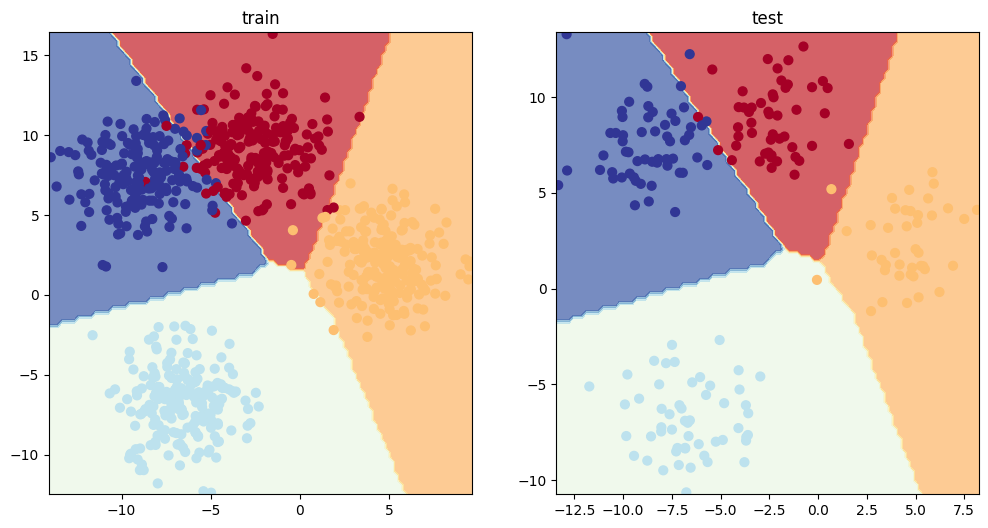

In [87]:
## visualize



plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_7,x_blob_train,y_blob_train)

plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_7,x_blob_test,y_blob_test)


In [88]:
# precision
from torchmetrics.classification import MulticlassPrecision,MulticlassRecall

precision=MulticlassPrecision(num_classes=4)
recall=MulticlassRecall(num_classes=4)
# correct=torch.eq(y_pred,y_test)
print(f"precision: {precision(y_pred,y_blob_test)} | Recall: {recall(y_pred,y_blob_test)}")

precision: 0.9715985059738159 | Recall: 0.9688289165496826


In [90]:
from torchmetrics.classification import MulticlassF1Score

F1_score=MulticlassF1Score(num_classes=4)

print(f"F1 Score: {F1_score(y_pred,y_blob_test)}")

F1 Score: 0.9700154066085815


In [92]:
from torchmetrics.classification import MulticlassConfusionMatrix

confmat = MulticlassConfusionMatrix(num_classes=4)

cm = confmat(y_pred, y_blob_test)

print(cm)

tensor([[47,  0,  0,  2],
        [ 1, 39,  1,  0],
        [ 0,  0, 53,  0],
        [ 2,  0,  0, 55]])


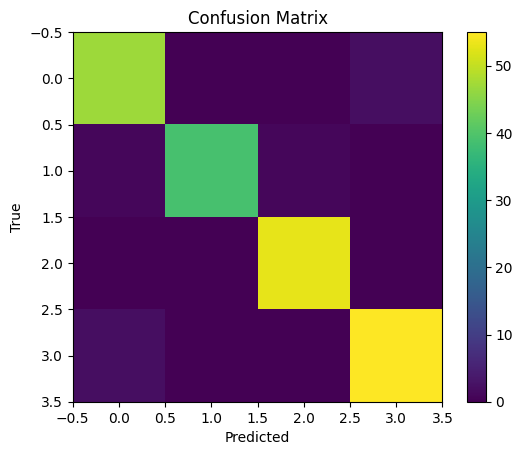

In [93]:
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()